In [1]:
import pandas
import numpy as np
import matplotlib.pyplot as plt

In [60]:
df1 = pandas.DataFrame(
    {
        "name": ["N1", "N2", "N3", "T1", "T2", "T3", "p1", "m1", "m2"],
        "MLE": np.array([1e4, 1e3, 3e4, 8e5, 1e5, 2e4, 0.025, 1e-4, 1e-6]),
        "CI_lower": 0.75 * np.array([1e4, 1e3, 3e4, 8e5, 1e5, 2e4, 0.025, 1e-4, 1e-6]),
        "CI_upper": 1.5 * np.array([1e4, 1e3, 3e4, 8e5, 1e5, 2e4, 0.025, 1e-4, 1e-6])
    }
)
print(df1)

df2 = pandas.DataFrame(
    {
        "name": ["N1", "N2", "N3", "T1", "T2", "T3", "p1", "m1", "m2"],
        "MLE": 1.1 * np.array([1e4, 1e3, 3e4, 8e5, 1e5, 2e4, 0.025, 1e-4, 1e-6]),
        "CI_lower": 0.8 * np.array([1e4, 1e3, 3e4, 8e5, 1e5, 2e4, 0.025, 1e-4, 1e-6]),
        "CI_upper": 1.55 * np.array([1e4, 1e3, 3e4, 8e5, 1e5, 2e4, 0.025, 1e-4, 1e-6])
    }
)
print(df2)

groups = [
    {"params": ["N1", "N2", "N3"], "log": True},
    {"params": ["T1", "T2"], "log": False},
    {"params": ["p1"], "log": False},
    {"params": ["m1", "m2"], "log": True},
]
                
labels = {
    "N1": "$N_1$",
    "N2": "$N_2$",
    "N3": "$N_3$",
    "m1": "$m_1$",
}

x_labels = ["Effective population size", "Years bp", "Pulse proportion", "Migration rate"]

  name            MLE      CI_lower      CI_upper
0   N1   10000.000000  7.500000e+03  1.500000e+04
1   N2    1000.000000  7.500000e+02  1.500000e+03
2   N3   30000.000000  2.250000e+04  4.500000e+04
3   T1  800000.000000  6.000000e+05  1.200000e+06
4   T2  100000.000000  7.500000e+04  1.500000e+05
5   T3   20000.000000  1.500000e+04  3.000000e+04
6   p1       0.025000  1.875000e-02  3.750000e-02
7   m1       0.000100  7.500000e-05  1.500000e-04
8   m2       0.000001  7.500000e-07  1.500000e-06
  name            MLE      CI_lower      CI_upper
0   N1   11000.000000  8.000000e+03  1.550000e+04
1   N2    1100.000000  8.000000e+02  1.550000e+03
2   N3   33000.000000  2.400000e+04  4.650000e+04
3   T1  880000.000000  6.400000e+05  1.240000e+06
4   T2  110000.000000  8.000000e+04  1.550000e+05
5   T3   22000.000000  1.600000e+04  3.100000e+04
6   p1       0.027500  2.000000e-02  3.875000e-02
7   m1       0.000110  8.000000e-05  1.550000e-04
8   m2       0.000001  8.000000e-07  1.550000e-06


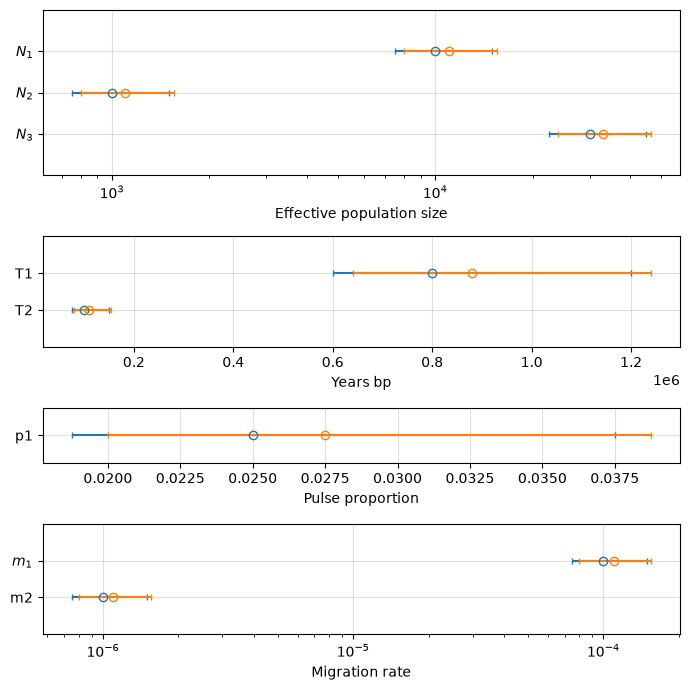

In [100]:
def plot_param_distributions(
    data,
    groups,
    x_labels=None,
    data_labels=None,
    param_labels=None,
    figsize=(6, 6),
    grid_alpha=0.4,
    spread=0.3,
    capsize=0,
):
    """
    Plot parameter MLE and CI from one or more datasets.

    Parameters
    ----------
    data : list of pandas.DataFrame
        Each dataframe should have columns 'name', 'MLE', 'CI_lower', 'CI_upper'
    groups : list of dict
        Assign parameters to figure panels; parameters left out are not plotted.
        Should have keys 'params' and 'log', with the latter a boolean
        specifying whether to use a log scale for the panel.
    x_labels : list
        Optional labels for panel x-axes
    data_labels : list
        Optional labels for datasets
    param_labels : dict
        Optional mapping of parameter names to labels. Not all parameters need
        to be included.
    figsize : tuple
    grid_alpha : float
    spread : float
        Spread of datasets on the y-axis. If 0, error bars overlap on the y-axis entirely.
    capsize : float
        Cap size for error bars. Useful when ``spread`` is 0.
    """
    n_datasets = len(data)
    n_groups = len(groups)
    group_lens = [len(x["params"]) for x in groups]

    fig, axs = plt.subplots(n_groups, 1, figsize=figsize, layout="tight", height_ratios=group_lens)

    for i, (group, ax) in enumerate(zip(groups, axs)):
        params = group["params"]
        for j, param in enumerate(params):
            ax.set_prop_cycle(None)
            for k, df in enumerate(data):
                row = df[df["name"] == param]
                mle = next(iter(row["MLE"]))
                lower = mle - next(iter(row["CI_lower"]))
                upper = next(iter(row["CI_upper"])) - mle
                offset = spread * ((n_datasets - 1) / 2 - k) / ((n_datasets - 1) / 2)
                ax.errorbar([mle], [-j + offset], xerr=[[lower], [upper]], fmt="o", mfc="none", capsize=capsize)

        # Label parameter values on the y axis
        group_param_labels = []
        for param in params:
            if param in param_labels:
                label = param_labels[param]
            else:
                label = param
            group_param_labels.append(label)
        ax.set_yticks(range(0, -len(params), -1), group_param_labels)
                
        if group["log"]:
            ax.set_xscale("log")
            
        if x_labels is not None:
            ax.set_xlabel(x_labels[i])
            
        ax.set_ylim(-len(params), 1)

        if grid_alpha > 0:
            ax.grid(alpha=grid_alpha)
    return


plot_param_distributions([df1, df2], groups, param_labels=labels, figsize=(7, 7), x_labels=x_labels, spread=0.0)

In [95]:
n_datasets = 3
for k in range(n_datasets):
    offset = ((n_datasets - 1) / 2 - k) / ((n_datasets - 1) / 2)
    print(offset)

1.0
0.0
-1.0
